# Predicting Businesses Closure- Classification
Our goal was to build a classifier that would predict restaurant will close or not based on the Yelp dataset. The motivation was to create a model that would give investors a chance to better asses the risk of bussiness failure and to provide them with information that would help them to make an informed decision whether they should invest in given business or not.

Here, in this script we tested several different machine learning classification algorithms to perform this task, which were all implemented using *Scikit-learn* machine learning library (https://scikit-learn.org/). The set of used classification features was already extracted previosuly from the dataset (see ***Build_dataset.ipynb***).

### Table of contents:
[(1) Logistic Regression](#lr)    
[(2) Random forest](#rf)   
[(3) Gaussian Naive Bayes](#gnb)   
[(4) Decision Tree](#dt)   
[(5) Multi-layer Perceptron](#mlp)   
[(6) Classifier Comparison](#comp)   
[(7) Summary](#sum)   
   
***Dataset info:***   
  
This dataset is imbalanced i.e. there were less samples of positive (business 'closed' 13%) than negative samples (business 'open' 86%). Therefore the accuracy (proportion of correctly and incorrectly classified labels) was inadequate as a performance metric. Instead, we used 'ROC' (receiver operating characteristic) and 'precision-recall' curves to compare the algorithms. See:    
*Davis, Jesse, and Mark Goadrich. "The relationship between Precision-Recall and ROC curves." Proceedings of the 23rd international conference on Machine learning. 2006.*

Also, where applicable, we used minority class upsampling (SMOTE) techniques to further deal with the imbalanced data:   
*Chawla, Nitesh V., et al. "SMOTE: synthetic minority over-sampling technique." Journal of artificial intelligence research 16 (2002): 321-357.*

***Classification model training:***   

The models were trained and evaluated using nested-crossvlidation approach. The 'inner' cross-validation loop was used to select (hyper)parameters of the model. The 'outer' crossvalidation loop was used to estimate generalization error by averaging test set scores over several (previously unseen) dataset splits. See:   
https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html



### Load preprocessed dataframe with extracted classification features

In [1]:
# Import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
feat_mat_clean = pd.read_csv('feat_mat_clean.csv')
feat_mat_clean.drop('Unnamed: 0',axis=1,inplace=True) 
feature_description = pd.read_csv('feature_description.csv',names=['feature','description']).drop(0)

### Feature Normalization

In [2]:
## Separate target label('is_open') from dataset
x = feat_mat_clean.drop(['is_open'],axis=1).iloc[:,:]
y = feat_mat_clean['is_open']
y=y.map({0: 'closed', 1: 'open'})

# Standardize features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
scaler.fit(x) 
x = pd.DataFrame(scaler.transform(x),columns = x.columns)

### Load ML Dependencies

In [3]:
from sklearn.model_selection import StratifiedKFold,KFold,GridSearchCV
from sklearn.metrics import auc,roc_auc_score, roc_curve,precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
from numpy import interp
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from matplotlib import gridspec


### Cross-validaton Score Calculation Class

In [4]:
class kfold_score_class:
    '''Class for keeping classification scores during crossvalidation
    
    Keeps ROC, PRE-REC, Confusion Mattrices over
    number of cross-validation folds and has methods
    for calculating the averages.

    '''
    
    def __init__(self):        
        self.fprs=None # ROC scores
        self.tprs=[]
        self.aucs=[]
        self.mean_aucs=None
        self.mean_fpr=np.linspace(0, 1, 100)
        self.mean_tpr=None
        self.std_tpr=None
        self.mean_auc=None
        self.std_auc=None
        
        self.recs=None  # Precision-recall scores
        self.pres=[]
        self.aps=[]
        self.mean_rec=np.linspace(1, 0, 1000);
        self.mean_pre=None
        self.std_pre=None                
        self.mean_ap=None
        self.std_ap=None
        
        self.conf_mat_arr=[] # Confusion matrix
        self.mean_conf_mat=None
        
    def aggr_kfold_stats(self,y_true,y_probas,y_pred,pos_label):    
        '''
        Appends current fold results to list of results

        '''
        
        # ROC
        fpr, tpr, thresholds = roc_curve(y_true,y_probas,pos_label)
        roc_auc=roc_auc_score(y_true,y_probas)
        interp_tpr = interp(self.mean_fpr, fpr, tpr)   
        interp_tpr[0] = 0.0
        self.tprs.append(interp_tpr)
        self.aucs.append(roc_auc)     

        # Precision-Recall
        precision,recall,thresholds=precision_recall_curve(y_true,y_probas,pos_label)
        average_precision=np.mean(precision)
        interp_pre = interp(self.mean_rec, np.flip(recall), np.flip(precision))    
        interp_pre[0] = 1.0
        self.pres.append(interp_pre)
        self.aps.append(average_precision) 

        # Confusion matrix    
        conf_mat = confusion_matrix(y_true, y_pred,normalize='true')
        self.conf_mat_arr.append(conf_mat) 

    def average_kfold_stats(self):
        '''
        Averages the results across folds

        '''
        
        # ROC
        self.mean_tpr=np.mean(self.tprs, axis=0)
        self.mean_tpr[-1] = 1.0
        self.std_tpr= np.std(self.tprs, axis=0)
        self.mean_auc = auc(self.mean_fpr, self.mean_tpr)
        self.std_auc = np.std(self.aucs)

        # Precision-Recall
        self.mean_pre = np.mean(self.pres, axis=0)
        self.mean_pre[0] = y.value_counts()[1]/len(y)
        self.std_pre=np.std(self.pres)
        self.mean_ap = np.mean(self.aps)
        self.std_ap = np.std(self.aps)
        
        # Confusion Matrix
        self.mean_conf_mat=np.mean(self.conf_mat_arr, axis=0)        

### Plotting functions

In [5]:
def plot_my_roc(ax,kfs): 
    ''' Plots ROC curve
    
    Parameters
    ----------
    ax: figure axis
    kfs: object (kfold_score_class)
    '''
   
    ax.plot(kfs.mean_fpr, kfs.mean_tpr, color='b', label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (kfs.mean_auc, kfs.std_auc), lw=2, alpha=.8)
    ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
    tprs_upper = np.minimum(kfs.mean_tpr + kfs.std_tpr, 1)
    tprs_lower = np.maximum(kfs.mean_tpr - kfs.std_tpr, 0)
    ax.set(xlim=[-0.05, 1.05], ylim=[-0.01, 1.01], title="Receiver operating characteristic")
    ax.legend(loc="lower right")
    ax.set(xlabel='False Positive')
    ax.set(ylabel='True Positive')

    
def plot_my_pre_rec(ax,kfs):
    ''' Plots Pre-Rec curve
    
    Parameters
    ----------
    ax: figure axis
    kfs: object (kfold_score_class)
    '''
    
    ax.plot(kfs.mean_rec, kfs.mean_pre, color='b', label=r'Mean Pre-Rec (AP = %0.2f $\pm$ %0.2f)' % (kfs.mean_ap, kfs.std_ap), lw=2, alpha=.8)
    ax.plot([0, 1], [y.value_counts()[1]/len(y), y.value_counts()[1]/len(y)],
                linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
    pres_upper = np.minimum(kfs.mean_pre + kfs.std_pre, 1)
    pres_lower = np.maximum(kfs.mean_rec - kfs.std_pre, 0)
    ax.set(xlim=[-0.01, 1.01], ylim=[y.value_counts()[1]/len(y)-0.01, 1.001], title="Precision-Recall")
    ax.legend(loc="upper right")
    ax.set(xlabel='Recall')
    ax.set(ylabel='Precision')
    
def plot_my_confusion(ax,kfs): 
    ''' Plots confusion matrix
    
    Parameters
    ----------
    ax: figure axis
    kfs: object (kfold_score_class)
    '''
     
    cmd = ConfusionMatrixDisplay(confusion_matrix=kfs.mean_conf_mat,
                                  display_labels=classifier.classes_)
    cmd.plot(include_values=True, xticks_rotation='horizontal', values_format=None,cmap='viridis', ax=ax)
    cmd.ax_.set_title('Confusion Matrix')
    
def plot_my_cofficients(ax):   
    ''' Plots LR coefficients
    
    Parameters
    ----------
    ax: figure axis
    '''
    
    if hasattr(classifier, 'coef_'): # for models not fitted usind CVgridSearchCV
        coef_sorted=pd.Series(data=-classifier.coef_[0],index=x.columns).sort_values() # minus sign to match our convention
                                                                                       # that 'close' is our positive class
    else:
        coef_sorted=pd.Series(data=-classifier.best_estimator_.coef_[0],index=x.columns).sort_values()       
    coef_plot=sns.barplot(x=coef_sorted.index,y=coef_sorted.values, ax=ax)                             
    coef_plot.set_xticklabels(coef_plot.get_xticklabels(), rotation=90);
    ax.set_title('Coefficients Logistic Regression');
    
def plot_my_feat_importances(ax):
    ''' Plots classifier importances
    
    Parameters
    ----------
    ax: figure axis
    '''
    
    importances = classifier.best_estimator_.feature_importances_
    importances_sorted=pd.Series(data=importances,index=x.columns).sort_values()        
    importances_plot=sns.barplot(x=importances_sorted.index,y=importances_sorted.values, ax=ax)
    importances_plot.set_xticklabels(importances_plot.get_xticklabels(), rotation=90);
    ax.set_title('Feature Importance');
        
def plot_my_importance_top10(ax,importances): 
    ''' Plots top ten features with decription
    
    Parameters
    ----------
    ax: figure axis
    importances: array of feature importances   
    ''' 
    
    my_palette=np.array(sns.color_palette("Blues",n_colors=15))
    my_palette=np.flip(my_palette,0);
    importances=pd.DataFrame(data=importances,index=x.columns).reset_index()
    importances.columns=(['feature','value'])
    importances=importances.merge(feature_description, on='feature')
    importances.sort_values(by='value',inplace=True,ascending=False);
    importances_plot=sns.barplot(x='value',y='description', data=importances.iloc[0:10,:],
                                 ax=ax,palette=my_palette)
    importances_plot.set_xticklabels(importances_plot.get_xticklabels(), rotation=90);
    importances_plot.set_xlabel('Relative Importance (Random Forest)')
    importances_plot.set_ylabel('Feature Description')
    ax.set_title('Feature Influence- TOP 10');
    
def plot_my_coefficients_top10(ax,coefs):
    ''' Plots coefficients with top ten magnitude with decription
    
    Parameters
    ----------
    ax: figure axis
    coefs: array of lr coefficients  
    ''' 
    importances=pd.DataFrame(data=-coefs,index=x.columns).reset_index()
    importances.columns=(['feature','value'])
    importances['abs_value']=np.abs(importances['value'])
    importances=importances.merge(feature_description, on='feature')
    importances.sort_values(by='abs_value',inplace=True,ascending=False);
    importances['sign']=np.sign(importances['value'])
    importances_plot=sns.barplot(x='abs_value',y='description', data=importances.iloc[0:10,:],ax=ax,ci=None,hue='sign',dodge=False)
    importances_plot.set_xticklabels(importances_plot.get_xticklabels(), rotation=90);
    importances_plot.set_xlabel('Coefficient Magnitude')
    importances_plot.set_ylabel('Feature Description')
    ax.set_title('Feature Influence- TOP 10');


# Classification
We wanted to build a prediction model that will estimate how likely will given businness close. For the sake of classification we define:   

***Closed Business - Positive observation***  
***Open Business- Negative observation***

In [6]:
# Lists to keep score for classifier comparison
mean_tpr_list=[];
mean_pre_list=[];
mean_auc=[];
mean_ap=[];
classifier_name_list=[];

### (0) Logistic Regression (default)

              precision    recall  f1-score   support

      closed       0.26      0.73      0.38      1801
        open       0.94      0.66      0.77     11175

    accuracy                           0.67     12976
   macro avg       0.60      0.69      0.58     12976
weighted avg       0.84      0.67      0.72     12976



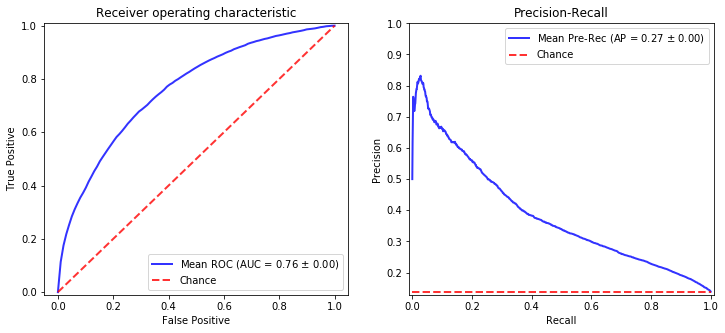

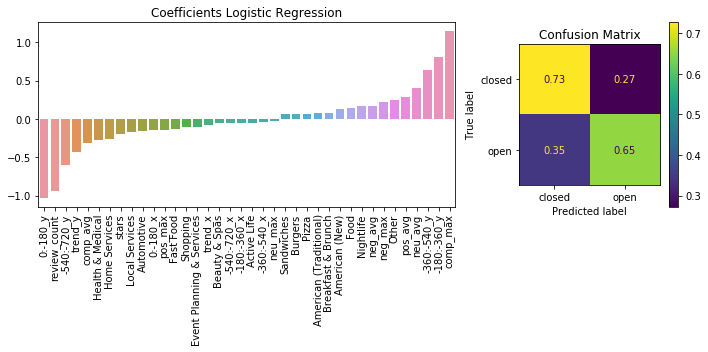

In [7]:
classifier=LogisticRegression(solver='lbfgs', max_iter=100,class_weight='balanced');

# Outer cross-validation
cv = StratifiedKFold(n_splits=4)

# Object for keeping score for each outer fold
kfold_score=kfold_score_class()


# Outer crossvalidation loop
for i, (train, test) in enumerate(cv.split(x, y)):         
    classifier.fit(x.iloc[train], y.iloc[train])  # train model    
    y_probas = classifier.predict_proba(x.iloc[test]) # get probabilities   
    y_pred=classifier.predict(x.iloc[test]) # get labels
    
    kfold_score.aggr_kfold_stats(y.iloc[test],y_probas[:,0],y_pred,'closed')
    
# average stats across folds
kfold_score.average_kfold_stats()

# plot results
fig, axs1 = plt.subplots(1,2,figsize=(12, 5)) 
plot_my_roc(axs1[0],kfold_score)
plot_my_pre_rec(axs1[1],kfold_score)

plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 6)
axs1=plt.subplot(gs[0:4])
axs2=plt.subplot(gs[4:6])
plot_my_cofficients(axs1)
plot_my_confusion(axs2,kfold_score)
plt.tight_layout()

print(classification_report(y.iloc[test],y_pred))

# Append results to list for class. algorithm comparison
mean_tpr_list.append(kfold_score.mean_tpr);
mean_pre_list.append(kfold_score.mean_pre);
mean_auc.append(kfold_score.mean_auc);
mean_ap.append(kfold_score.mean_ap);
classifier_name_list.append('Logistic Regression (def)')


### (1) Logistic Regression (C tuned) <a class="anchor" id="lr"></a>

,params,mean_test_score
0,"{'C': 1e-05, 'penalty': 'l2', 'solver': 'lbfgs'}",0.698251
1,"{'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}",0.745682
2,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.760381
3,"{'C': 1000.0, 'penalty': 'l2', 'solver': 'lbfgs'}",0.760328
4,"{'C': 100000.0, 'penalty': 'l2', 'solver': 'lb...",0.760378


              precision    recall  f1-score   support

      closed       0.26      0.73      0.38      1801
        open       0.94      0.66      0.77     11175

    accuracy                           0.67     12976
   macro avg       0.60      0.69      0.58     12976
weighted avg       0.84      0.67      0.72     12976



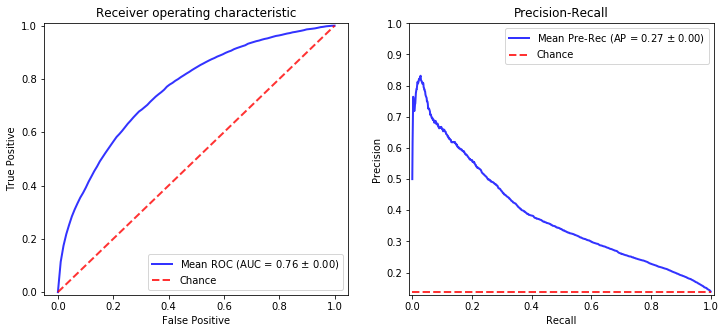

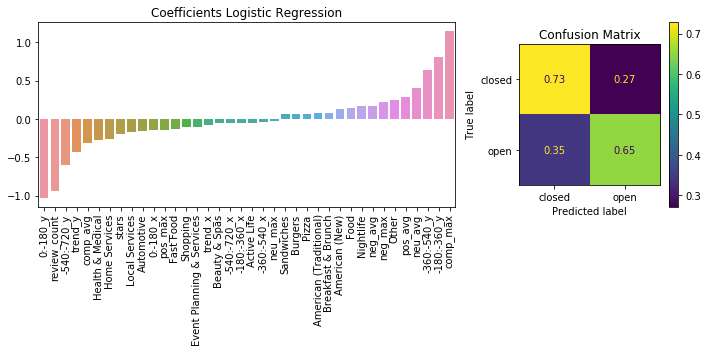

In [8]:
clf=LogisticRegression(solver='lbfgs', max_iter=1000,class_weight='balanced');
#p_grid = {'C': [1e-3, 1, 1e3],'penalty':['l1','l2'],solver=['liblinear']}
p_grid = {'C': [1e-5,1e-3, 1, 1e3,1e5],'penalty':['l2'],'solver':['lbfgs']}

# Outer cross-validation
cv = StratifiedKFold(n_splits=4)

# Object for keeping score for each outer fold
kfold_score=kfold_score_class()

# Outer crossvalidation loop
for i, (train, test) in enumerate(cv.split(x, y)): 

    #training data
    x_train=x.iloc[train]
    y_train=y.iloc[train]
    
    #validation data    
    x_test=x.iloc[test]
    y_test=y.iloc[test]
           
    # x_train, y_train = SMOTE().fit_resample(x_train, y_train) # Synthetic Minority Oversampling Technique (SMOTE)
           
    inner_cv = KFold(n_splits=4, shuffle=True) # used for param tuning
    classifier = GridSearchCV(estimator=clf, param_grid=p_grid, cv=inner_cv,scoring='roc_auc')
    classifier.fit(x_train, y_train)
 
    y_probas = classifier.predict_proba(x.iloc[test]) # get probabilities   
    y_pred=classifier.predict(x.iloc[test]) # get labels
    
    kfold_score.aggr_kfold_stats(y.iloc[test],y_probas[:,0],y_pred,'closed')
    
# average stats across folds
kfold_score.average_kfold_stats()

# plot results
fig, axs1 = plt.subplots(1,2,figsize=(12, 5)) 
plot_my_roc(axs1[0],kfold_score)
plot_my_pre_rec(axs1[1],kfold_score)

plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 6)
axs1=plt.subplot(gs[0:4])
axs2=plt.subplot(gs[4:6])
plot_my_cofficients(axs1)
plot_my_confusion(axs2,kfold_score)
plt.tight_layout()

# print Grid search scores with params
display(pd.DataFrame(classifier.cv_results_)[['params','mean_test_score']].head())

# print classification report for default threshold (0.5)
print(classification_report(y.iloc[test],y_pred))

# Append results to list for class. algorithm comparison
mean_tpr_list.append(kfold_score.mean_tpr);
mean_pre_list.append(kfold_score.mean_pre);
mean_auc.append(kfold_score.mean_auc);
mean_ap.append(kfold_score.mean_ap);
classifier_name_list.append('Logistic Regression (C Tuned)')

coefs_for_summary=classifier.best_estimator_.coef_[0];


### (2) RandomForest <a class="anchor" id="rf"></a>

,params,mean_test_score
0,{'n_estimators': 5},0.702805
1,{'n_estimators': 10},0.721428
2,{'n_estimators': 30},0.728365
3,{'n_estimators': 40},0.728343


              precision    recall  f1-score   support

      closed       0.23      0.72      0.35      1801
        open       0.93      0.62      0.74     11175

    accuracy                           0.63     12976
   macro avg       0.58      0.67      0.55     12976
weighted avg       0.84      0.63      0.69     12976



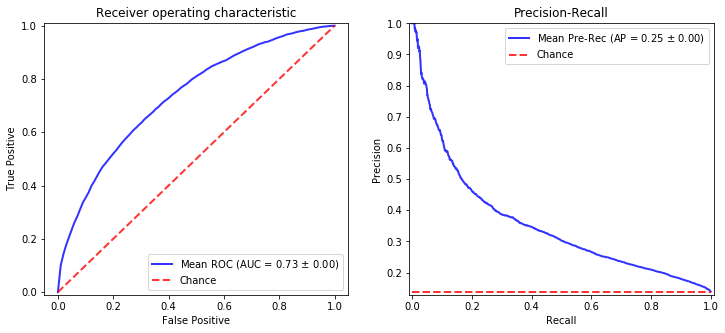

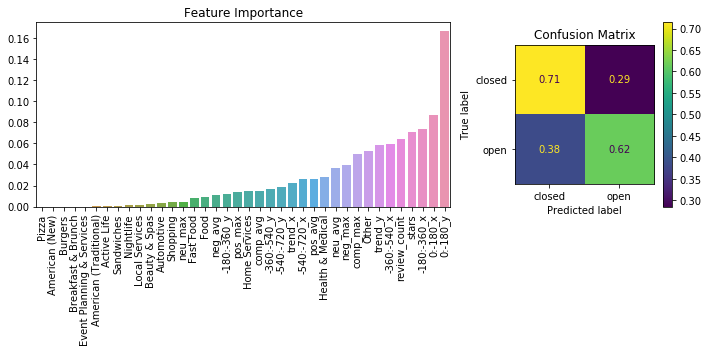

In [9]:
clf=RandomForestClassifier(class_weight='balanced',max_depth=5);
p_grid = {'n_estimators': [5,10,30,40]}

# Outer cross-validation
cv = StratifiedKFold(n_splits=4)

# Object for keeping score for each outer fold
kfold_score=kfold_score_class()

# Outer crossvalidation loop
for i, (train, test) in enumerate(cv.split(x, y)): 

    #training data
    x_train=x.iloc[train]
    y_train=y.iloc[train]
    
    #validation data    
    x_test=x.iloc[test]
    y_test=y.iloc[test]
       
    # x_train, y_train = SMOTE().fit_resample(x_train, y_train) # Synthetic Minority Oversampling Technique (SMOTE)
           
    inner_cv = KFold(n_splits=4, shuffle=True) # used for param tuning
    classifier = GridSearchCV(estimator=clf, param_grid=p_grid, cv=inner_cv,scoring='roc_auc')
    classifier.fit(x_train, y_train)
 
    y_probas = classifier.predict_proba(x.iloc[test]) # get probabilities   
    y_pred=classifier.predict(x.iloc[test]) # get labels
    
    kfold_score.aggr_kfold_stats(y.iloc[test],y_probas[:,0],y_pred,'closed')
    
# average stats across folds
kfold_score.average_kfold_stats()

# plot results
fig, axs1 = plt.subplots(1,2,figsize=(12, 5)) 
plot_my_roc(axs1[0],kfold_score)
plot_my_pre_rec(axs1[1],kfold_score)
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 6)
axs1=plt.subplot(gs[0:4])
axs2=plt.subplot(gs[4:6])
plot_my_feat_importances(axs1)
plot_my_confusion(axs2,kfold_score)
plt.tight_layout()

# print Grid search scores with params
display(pd.DataFrame(classifier.cv_results_)[['params','mean_test_score']].head())

# print classification report for default threshold (0.5)
print(classification_report(y.iloc[test],y_pred))

# Append results to list for class. algorithm comparison
mean_tpr_list.append(kfold_score.mean_tpr);
mean_pre_list.append(kfold_score.mean_pre);
mean_auc.append(kfold_score.mean_auc);
mean_ap.append(kfold_score.mean_ap);
classifier_name_list.append('Random Forest')

importance_for_summary=classifier.best_estimator_.feature_importances_;


### (3) Gaussian Naive Bayes <a class="anchor" id="gnb"></a>

,params,mean_test_score
0,{'var_smoothing': 1e-12},0.698282


              precision    recall  f1-score   support

      closed       0.20      0.77      0.32      1801
        open       0.93      0.52      0.67     11175

    accuracy                           0.55     12976
   macro avg       0.57      0.64      0.49     12976
weighted avg       0.83      0.55      0.62     12976



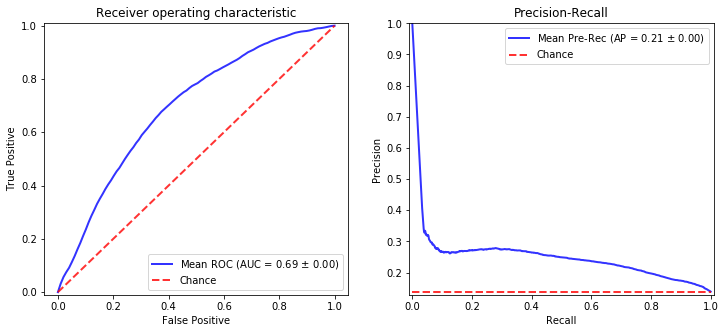

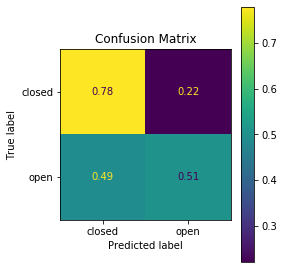

In [10]:
clf=GaussianNB();
p_grid = {'var_smoothing':[1e-12]}

# Outer cross-validation
cv = StratifiedKFold(n_splits=4)

# Object for keeping score for each outer fold
kfold_score=kfold_score_class()

# Outer crossvalidation loop
for i, (train, test) in enumerate(cv.split(x, y)): 

    #training data
    x_train=x.iloc[train]
    y_train=y.iloc[train]
    
    #validation data    
    x_test=x.iloc[test]
    y_test=y.iloc[test]
       
    #x_train, y_train = SMOTE().fit_resample(x_train, y_train) # Synthetic Minority Oversampling Technique (SMOTE)
           
    inner_cv = KFold(n_splits=4, shuffle=True) # used for param tuning
    classifier = GridSearchCV(estimator=clf, param_grid=p_grid, cv=inner_cv,scoring='roc_auc')
    classifier.fit(x_train, y_train)
 
    y_probas = classifier.predict_proba(x.iloc[test]) # get probabilities   
    y_pred=classifier.predict(x.iloc[test]) # get labels
    
    kfold_score.aggr_kfold_stats(y.iloc[test],y_probas[:,0],y_pred,'closed')
    
# average stats across folds
kfold_score.average_kfold_stats()

# plot results
fig, axs1 = plt.subplots(1,2,figsize=(12, 5)) 
plot_my_roc(axs1[0],kfold_score)
plot_my_pre_rec(axs1[1],kfold_score)
fig, ax = plt.subplots(1,1,figsize=(4, 4)) 
plot_my_confusion(ax,kfold_score)
plt.tight_layout()

# print Grid search scores with params
display(pd.DataFrame(classifier.cv_results_)[['params','mean_test_score']].head())

# print classification report for default threshold (0.5)
print(classification_report(y.iloc[test],y_pred))

# Append results to list for class. algorithm comparison
mean_tpr_list.append(kfold_score.mean_tpr);
mean_pre_list.append(kfold_score.mean_pre);
mean_auc.append(kfold_score.mean_auc);
mean_ap.append(kfold_score.mean_ap);
classifier_name_list.append('Gaussian Naive Bayes')

### (4) Decision Tree  <a class="anchor" id="dt"></a>

,params,mean_test_score
0,"{'criterion': 'gini', 'max_depth': 5}",0.675708
1,"{'criterion': 'gini', 'max_depth': 10}",0.679960
2,"{'criterion': 'gini', 'max_depth': 15}",0.633677
3,"{'criterion': 'gini', 'max_depth': 20}",0.599348
4,"{'criterion': 'gini', 'max_depth': 30}",0.573730


              precision    recall  f1-score   support

      closed       0.23      0.64      0.33      1801
        open       0.92      0.65      0.76     11175

    accuracy                           0.65     12976
   macro avg       0.57      0.64      0.55     12976
weighted avg       0.82      0.65      0.70     12976



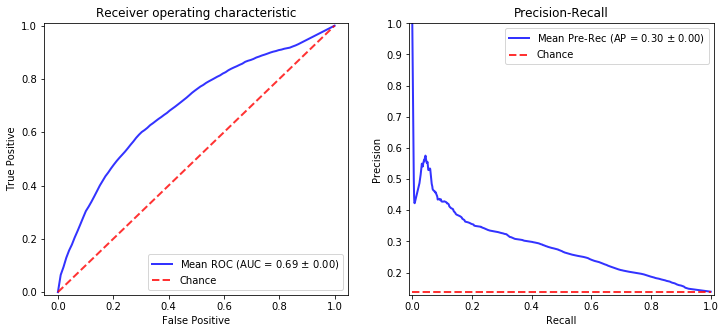

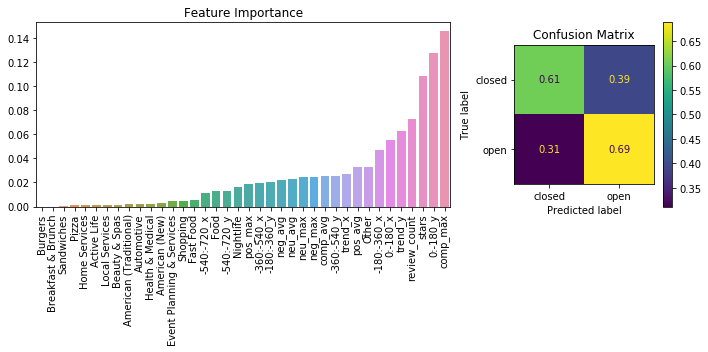

In [11]:
clf=DecisionTreeClassifier(class_weight='balanced');
p_grid = {'max_depth':[5,10,15,20,30],'criterion':["gini"]}

# Outer cross-validation
cv = StratifiedKFold(n_splits=4)

# Object for keeping score for each outer fold
kfold_score=kfold_score_class()

# Outer crossvalidation loop
for i, (train, test) in enumerate(cv.split(x, y)): 

    #training data
    x_train=x.iloc[train]
    y_train=y.iloc[train]
    
    #validation data    
    x_test=x.iloc[test]
    y_test=y.iloc[test]
       
    # x_train, y_train = SMOTE().fit_resample(x_train, y_train) # Synthetic Minority Oversampling Technique (SMOTE)
              
    inner_cv = KFold(n_splits=4, shuffle=True) # used for param tuning
    classifier = GridSearchCV(estimator=clf, param_grid=p_grid, cv=inner_cv,scoring='roc_auc')
    classifier.fit(x_train, y_train)
 
    y_probas = classifier.predict_proba(x.iloc[test]) # get probabilities   
    y_pred=classifier.predict(x.iloc[test]) # get labels
    
    kfold_score.aggr_kfold_stats(y.iloc[test],y_probas[:,0],y_pred,'closed')
    
# average stats across folds
kfold_score.average_kfold_stats()

# plot results
fig, axs1 = plt.subplots(1,2,figsize=(12, 5)) 
plot_my_roc(axs1[0],kfold_score)
plot_my_pre_rec(axs1[1],kfold_score)
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 6)
axs1=plt.subplot(gs[0:4])
axs2=plt.subplot(gs[4:6])
plot_my_feat_importances(axs1)
plot_my_confusion(axs2,kfold_score)
plt.tight_layout()


# print Grid search scores with params
display(pd.DataFrame(classifier.cv_results_)[['params','mean_test_score']].head())

# print classification report for default threshold (0.5)
print(classification_report(y.iloc[test],y_pred))

# Append results to list for class. algorithm comparison
mean_tpr_list.append(kfold_score.mean_tpr);
mean_pre_list.append(kfold_score.mean_pre);
mean_auc.append(kfold_score.mean_auc);
mean_ap.append(kfold_score.mean_ap);
classifier_name_list.append('Decision Tree')

### (5) MLPC (Multi-layer Perceptron classifier)  <a class="anchor" id="mlp"></a>

,params,mean_test_score
0,"{'alpha': 0.1, 'hidden_layer_sizes': 100}",0.865259


              precision    recall  f1-score   support

      closed       0.29      0.64      0.40      1801
        open       0.93      0.74      0.83     11175

    accuracy                           0.73     12976
   macro avg       0.61      0.69      0.61     12976
weighted avg       0.84      0.73      0.77     12976



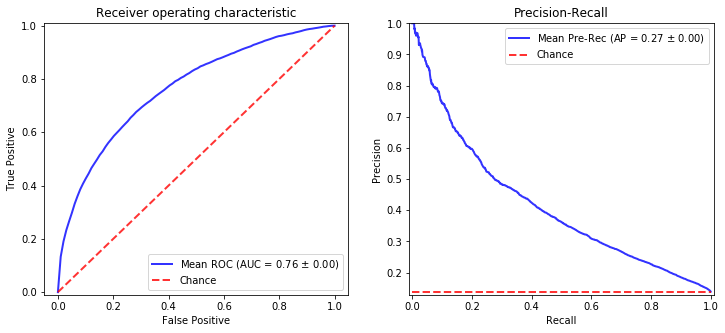

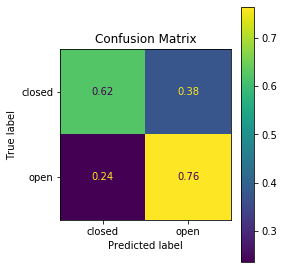

In [12]:
clf=MLPClassifier();
p_grid = {'alpha':[0.1],'hidden_layer_sizes':[100]}

# Outer cross-validation
cv = StratifiedKFold(n_splits=4)

# Object for keeping score for each outer fold
kfold_score=kfold_score_class()

# Outer crossvalidation loop
for i, (train, test) in enumerate(cv.split(x, y)): 

    #training data
    x_train=x.iloc[train]
    y_train=y.iloc[train]
    
    #validation data    
    x_test=x.iloc[test]
    y_test=y.iloc[test]
           
    x_train, y_train = SMOTE().fit_resample(x_train, y_train) # Synthetic Minority Oversampling Technique (SMOTE)
           
    inner_cv = KFold(n_splits=4, shuffle=True) # used for param tuning
    classifier = GridSearchCV(estimator=clf, param_grid=p_grid, cv=inner_cv,scoring='roc_auc')
    classifier.fit(x_train, y_train)
 
    y_probas = classifier.predict_proba(x.iloc[test]) # get probabilities   
    y_pred=classifier.predict(x.iloc[test]) # get labels
    
    kfold_score.aggr_kfold_stats(y.iloc[test],y_probas[:,0],y_pred,'closed')
    
# average stats across folds
kfold_score.average_kfold_stats()

# plot results
fig, axs1 = plt.subplots(1,2,figsize=(12, 5)) 
plot_my_roc(axs1[0],kfold_score)
plot_my_pre_rec(axs1[1],kfold_score)

fig, ax = plt.subplots(1,1,figsize=(4, 4)) 
plot_my_confusion(ax,kfold_score)
plt.tight_layout()


# print Grid search scores with params
display(pd.DataFrame(classifier.cv_results_)[['params','mean_test_score']].head())

# print classification report for default threshold (0.5)
print(classification_report(y.iloc[test],y_pred))

# Append results to list for class. algorithm comparison
mean_tpr_list.append(kfold_score.mean_tpr);
mean_pre_list.append(kfold_score.mean_pre);
mean_auc.append(kfold_score.mean_auc);
mean_ap.append(kfold_score.mean_ap);
classifier_name_list.append('MLPC')

### (6) Classifier Comparison <a class="anchor" id="comp"></a>

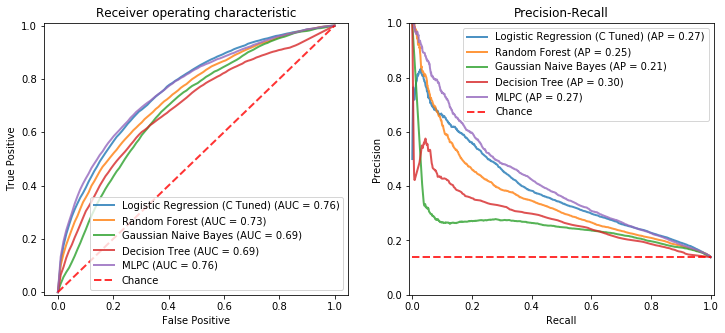

In [13]:
# Plot ROC & Precision-Recall for all classifiers
fig, axs = plt.subplots(1,2,figsize=(12, 5)) 
for i in range(1,len(classifier_name_list)):
    # ROC figure
    axs[0].plot(kfold_score.mean_fpr, mean_tpr_list[i], label=r'%s (AUC = %0.2f)' % (classifier_name_list[i],mean_auc[i]), lw=2, alpha=.8)
    axs[1].plot(kfold_score.mean_rec, mean_pre_list[i], label=r'%s (AP = %0.2f)' % (classifier_name_list[i],mean_ap[i]), lw=2, alpha=.8)
axs[0].plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
axs[1].plot([0, 1], [y.value_counts()[1]/len(y), y.value_counts()[1]/len(y)],
        linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
axs[0].set(xlim=[-0.05, 1.05], ylim=[-0.01, 1.01], title="Receiver operating characteristic")
axs[0].legend(loc="lower right")
axs[0].set(xlabel='False Positive')
axs[0].set(ylabel='True Positive')
axs[1].set(xlim=[-0.01, 1.01], ylim=[0, 1.001], title="Precision-Recall")
axs[1].legend(loc="upper right")
axs[1].set(xlabel='Recall')
axs[1].set(ylabel='Precision');

### (7) Summary <a class="anchor" id="sum"></a> <br>

* Here, we wanted build a classification model that will successfully predict business closure from the Yelp review dataset. This model would be potentially useful for banks and/or investors to help them decide whether they should invest in given business. <br><br>    
* The initial data exploration showed there is no obvious feature from the Yelp dataset that would clearly separated the classeses (open/close business). <br><br>      
* However, here, we showed it is possible to build a machine-learning classification model that will successfully predict business closure from the Yelp review dataset.<br><br> 
* We have tested several different algorithms from simple logistic regression model to more complicated artificial neural network and found that all tested classification models perform better than no-skill classifier (chance) in predicting business closure based on ROC and precision-recall curves.<br><br>
* The performances of all models were comparable. Nevertheless, logistic regression and artificial feed-forward neural network (Multi-layer Perceptron classifier) performed the best.<br><br> 
* With respect to classification features that were driving the decoding (see fig below), we found that number of reviews and review sentiment were most useful for classsification.<br><br>
* In particular, the Vader sentiment analyses show that more useful information (beyond score and # reviews of the original Yelp dataset) can be extracted from the text content of the user reviews. This might be explored in future work. <br><br>

Limitations:
* Due to limited time for this project, I have restricted my analysis to 'business' and 'review' dataframes. Also not all features of these frames were fully utilized e.g. the geolocation information was not used for classification although it might have been potentially useful. In future work, it would be interesting to deploy automated feature engineering framework such as https://docs.featuretools.com/, which would possibly help to extract more information from the dataset. <br><br>
* Classification model hyper-parameters were not fine-tuned due to time-constraints. The results might possibly differ when fitting the models properly.  



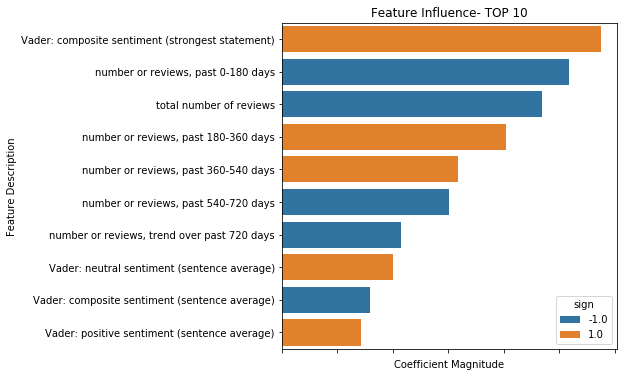

In [17]:
fig, ax = plt.subplots(1,1,figsize=(6, 6)) 
plot_my_coefficients_top10(ax,coefs_for_summary)
plt.

Feature importance estimated from logistic regression coefficients:

* Orange bars (positive sign): large values of the corresponding feature push the probability towards label 'close'  
* Blue bars (negative sign): large values of the corresponding feature push the probability towards label 'open'